### 1. Apply ro5 rules to CDK2_coumpounds dataset

In [58]:
from pathlib import Path
import math
import os
from pathlib import Path
from tqdm.auto import tqdm


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw, PandasTools
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

We detect available csv files :

In [59]:
BASE_DIR = Path("/home/adem/Downloads/Drug Discovery journey/Mastering Generative_ml models")

csv_files = sorted(BASE_DIR.rglob("*.csv"))

for i, path in enumerate(csv_files):
    rel_path = path.relative_to(BASE_DIR)
    size_kb = path.stat().st_size / 1024
    print(f"[{i}] {rel_path}  ({size_kb:.1f} KB)")

[0] Phase_0/VAE/project_01/phase_01/.ipynb_checkpoints/2.CDK2_compounds_lipinski-checkpoint.csv  (257.7 KB)
[1] Phase_0/VAE/project_01/phase_01/.ipynb_checkpoints/3.CDK2_compounds_lipinski_NOPAINS_NOBRENKS-checkpoint.csv  (278.0 KB)
[2] Phase_0/VAE/project_01/phase_01/1.CDK2_compounds.csv  (190.4 KB)
[3] Phase_0/VAE/project_01/phase_01/2.CDK2_compounds_lipinski.csv  (257.7 KB)
[4] Phase_0/VAE/project_01/phase_01/3.CDK2_compounds_lipinski_NOPAINS_NOBRENKS.csv  (278.0 KB)
[5] Phase_0/VAE/project_01/phase_01/data/.ipynb_checkpoints/CDK_compounds-checkpoint.csv  (692.7 KB)
[6] Phase_0/VAE/project_01/phase_01/data/CDK_compounds.csv  (692.7 KB)


We choose 1.CDK2_compounds.csv

In [60]:
selected_index = 6
csv_path = csv_files[selected_index]
print(f"Loading: {csv_path}")

cdk2_compounds_df = pd.read_csv(csv_path)
cdk2_compounds_df.head()

Loading: /home/adem/Downloads/Drug Discovery journey/Mastering Generative_ml models/Phase_0/VAE/project_01/phase_01/data/CDK_compounds.csv


,molecule_chembl_id,kinase,IC50,units,canonical_smiles,pIC50
0,CHEMBL3694408,CDK9,0.005,nM,COc1ccc(F)cc1-c1cc(NC(=O)COc2ccc(Cl)cn2)ncn1,11.301030
1,CHEMBL334285,CDK4,0.007,nM,O=C(Nc1cccc2c1C(=O)c1c(-c3ccc(C(=O)N4CCNCC4)s3...,11.154902
2,CHEMBL3694406,CDK9,0.015,nM,COc1ccc(F)cc1-c1cc(NC(=O)Cc2cccnc2)ncn1,10.823909
3,CHEMBL3694400,CDK9,0.018,nM,COc1ccc(F)cc1-c1cc(NC(=O)C2CCCNC2)ncn1,10.744727
4,CHEMBL3694402,CDK9,0.019,nM,COc1ccccc1-c1cc(NC(=O)C2CCC(=O)NC2)ncn1,10.721246


In [61]:
cdk2_compounds_df.shape

(6999, 6)

We define the function that checks if a molecule fulfill at least 3 conditions --> So it will be accepted.

In [62]:
def ro5_properties_checker(smile):
    
    #RD-kit molecule from SMILES
    molecule = Chem.MolFromSmiles(smile)
    
    #caluclate ro5 parameters 
    molecular_weight = Descriptors.ExactMolWt(molecule)
    nbr_hba = Descriptors.NumHAcceptors(molecule)
    nbr_hbd = Descriptors.NumHDonors(molecule)
    logp = Descriptors.MolLogP(molecule)

    
    #check if ro5 condition is fulffilled
    conditions = [molecular_weight <= 500,
                 nbr_hba <= 10,
                 nbr_hbd <= 5, 
                 logp <= 5]

    ro5_fullfilled = sum(conditions)>=3
    
    ro5_df = pd.Series([molecular_weight, nbr_hba, nbr_hbd, logp, ro5_fullfilled],
        index = ["molecular_weight", "n_hba", "n_hbd", "logp", "ro5_fulfilled"])
    
    return ro5_df

In [63]:
ro5_properties = cdk2_compounds_df['canonical_smiles'].apply(ro5_properties_checker)
ro5_properties

,molecular_weight,n_hba,n_hbd,logp,ro5_fulfilled
0,388.073846,6,1,3.3572,True
1,507.168873,8,4,1.7637,True
2,338.117904,5,1,2.8675,True
3,330.149204,5,2,2.2294,True
4,326.137890,5,2,1.6169,True
...,...,...,...,...,...
6994,496.215365,6,2,5.9668,True
6995,395.243359,7,1,2.7797,True
6996,403.188736,7,4,3.8152,True
6997,403.188736,7,4,3.8152,True


Next, we concatenate the cdk2_coumpounds dataset with ro5_properties dataset

In [64]:
cdk2_compounds_df = pd.concat([cdk2_compounds_df, ro5_properties], axis=1)
cdk2_compounds_df.head()

,molecule_chembl_id,kinase,IC50,units,canonical_smiles,pIC50,molecular_weight,n_hba,n_hbd,logp,ro5_fulfilled
0,CHEMBL3694408,CDK9,0.005,nM,COc1ccc(F)cc1-c1cc(NC(=O)COc2ccc(Cl)cn2)ncn1,11.301030,388.073846,6,1,3.3572,True
1,CHEMBL334285,CDK4,0.007,nM,O=C(Nc1cccc2c1C(=O)c1c(-c3ccc(C(=O)N4CCNCC4)s3...,11.154902,507.168873,8,4,1.7637,True
2,CHEMBL3694406,CDK9,0.015,nM,COc1ccc(F)cc1-c1cc(NC(=O)Cc2cccnc2)ncn1,10.823909,338.117904,5,1,2.8675,True
3,CHEMBL3694400,CDK9,0.018,nM,COc1ccc(F)cc1-c1cc(NC(=O)C2CCCNC2)ncn1,10.744727,330.149204,5,2,2.2294,True
4,CHEMBL3694402,CDK9,0.019,nM,COc1ccccc1-c1cc(NC(=O)C2CCC(=O)NC2)ncn1,10.721246,326.137890,5,2,1.6169,True


In [65]:
cdk2_compounds_ro5_fulfilled = cdk2_compounds_df[cdk2_compounds_df['ro5_fulfilled']]
cdk2_compounds_ro5__violated = cdk2_compounds_df[~cdk2_compounds_df['ro5_fulfilled']]


print(f'- Initial number of compounds {cdk2_compounds_df.shape[0]}')
print(f'- Compounds fulfilling Ro5: {cdk2_compounds_ro5_fulfilled.shape[0]}')
print(f'- Compounds violating Ro5: {cdk2_compounds_ro5__violated.shape[0]}')

- Initial number of compounds 6999
- Compounds fulfilling Ro5: 6497
- Compounds violating Ro5: 502


In [66]:
cdk2_compounds_ro5_fulfilled.reset_index(drop=True, inplace=True)

In [67]:
cdk2_compounds_ro5_fulfilled.head()

,molecule_chembl_id,kinase,IC50,units,canonical_smiles,pIC50,molecular_weight,n_hba,n_hbd,logp,ro5_fulfilled
0,CHEMBL3694408,CDK9,0.005,nM,COc1ccc(F)cc1-c1cc(NC(=O)COc2ccc(Cl)cn2)ncn1,11.301030,388.073846,6,1,3.3572,True
1,CHEMBL334285,CDK4,0.007,nM,O=C(Nc1cccc2c1C(=O)c1c(-c3ccc(C(=O)N4CCNCC4)s3...,11.154902,507.168873,8,4,1.7637,True
2,CHEMBL3694406,CDK9,0.015,nM,COc1ccc(F)cc1-c1cc(NC(=O)Cc2cccnc2)ncn1,10.823909,338.117904,5,1,2.8675,True
3,CHEMBL3694400,CDK9,0.018,nM,COc1ccc(F)cc1-c1cc(NC(=O)C2CCCNC2)ncn1,10.744727,330.149204,5,2,2.2294,True
4,CHEMBL3694402,CDK9,0.019,nM,COc1ccccc1-c1cc(NC(=O)C2CCC(=O)NC2)ncn1,10.721246,326.137890,5,2,1.6169,True


### 2. Visualize Ro5 properties (radar plot)

Radar plot uses **mean** and **std** calculated from our dataset. so we need to calculate for each rule : 

    mean    
    std

In [68]:
def calculate_mean_std(dataframe):
    """
    Calculate the mean and standard deviation of a dataset.

    Parameters
    ----------
    dataframe : pd.DataFrame
        Properties (columns) for a set of items (rows).

    Returns
    -------
    pd.DataFrame
        Mean and standard deviation (columns) for different properties (rows).
    """
    # Generate descriptive statistics for property columns
    stats = dataframe.describe()
    # Transpose DataFrame (statistical measures = columns)
    stats = stats.T
    # Select mean and standard deviation
    stats = stats[["mean", "std"]]
    return stats

In [69]:
cdk2_compounds_ro5_fulfilled_stats = calculate_mean_std(
    cdk2_compounds_ro5_fulfilled[["molecular_weight", "n_hba", "n_hbd", "logp"]]
)

cdk2_compounds_ro5_fulfilled_stats

,mean,std
molecular_weight,429.214302,71.762262
n_hba,6.032323,1.754183
n_hbd,2.124211,0.904011
logp,3.679262,1.080344


rescaltion step: 

In [70]:
def _scale_by_thresholds(stats, thresholds, scaled_threshold):
    """
    Scale values for different properties that have each an individually defined threshold.

    Parameters
    ----------
    stats : pd.DataFrame
        Dataframe with "mean" and "std" (columns) for each physicochemical property (rows).
    thresholds : dict of str: int
        Thresholds defined for each property.
    scaled_threshold : int or float
        Scaled thresholds across all properties.

    Returns
    -------
    pd.DataFrame
        DataFrame with scaled means and standard deviations for each physiochemical property.
    """
    # Raise error if scaling keys and data_stats indicies are not matching
    for property_name in stats.index:
        if property_name not in thresholds.keys():
            raise KeyError(f"Add property '{property_name}' to scaling variable.")
    # Scale property data
    stats_scaled = stats.apply(lambda x: x / thresholds[x.name] * scaled_threshold, axis=1)
    return stats_scaled

In [71]:
def _define_radial_axes_angles(n_axes):
    """Define angles (radians) for radial (x-)axes depending on the number of axes."""
    x_angles = [i / float(n_axes) * 2 * math.pi for i in range(n_axes)]
    x_angles += x_angles[:1]
    return x_angles

In [72]:
def plot_radar(
    y,
    thresholds,
    scaled_threshold,
    properties_labels,
    y_max=None,
    output_path=None,
):
    """
    Plot a radar chart based on the mean and standard deviation of a data set's properties.

    Parameters
    ----------
    y : pd.DataFrame
        Dataframe with "mean" and "std" (columns) for each physicochemical property (rows).
    thresholds : dict of str: int
        Thresholds defined for each property.
    scaled_threshold : int or float
        Scaled thresholds across all properties.
    properties_labels : list of str
        List of property names to be used as labels in the plot.
    y_max : None or int or float
        Set maximum y value. If None, let matplotlib decide.
    output_path : None or pathlib.Path
        If not None, save plot to file.
    """

    # Define radial x-axes angles -- uses our helper function!
    x = _define_radial_axes_angles(len(y))
    # Scale y-axis values with respect to a defined threshold -- uses our helper function!
    y = _scale_by_thresholds(y, thresholds, scaled_threshold)
    # Since our chart will be circular we append the first value of each property to the end
    y = pd.concat([y, y.head(1)])

    # Set figure and subplot axis
    plt.figure(figsize=(6, 6))
    ax = plt.subplot(111, polar=True)

    # Plot data
    ax.fill(x, [scaled_threshold] * len(x), "cornflowerblue", alpha=0.2)
    ax.plot(x, y["mean"], "b", lw=3, ls="-")
    ax.plot(x, y["mean"] + y["std"], "orange", lw=2, ls="--")
    ax.plot(x, y["mean"] - y["std"], "orange", lw=2, ls="-.")

    # From here on, we only do plot cosmetics
    # Set 0° to 12 o'clock
    ax.set_theta_offset(math.pi / 2)
    # Set clockwise rotation
    ax.set_theta_direction(-1)

    # Set y-labels next to 180° radius axis
    ax.set_rlabel_position(180)
    # Set number of radial axes' ticks and remove labels
    plt.xticks(x, [])
    # Get maximal y-ticks value
    if not y_max:
        y_max = int(ax.get_yticks()[-1])
    # Set axes limits
    plt.ylim(0, y_max)
    # Set number and labels of y axis ticks
    plt.yticks(
        range(1, y_max),
        ["5" if i == scaled_threshold else "" for i in range(1, y_max)],
        fontsize=16,
    )

    # Draw ytick labels to make sure they fit properly
    # Note that we use [:1] to exclude the last element which equals the first element (not needed here)
    for i, (angle, label) in enumerate(zip(x[:-1], properties_labels)):
        if angle == 0:
            ha = "center"
        elif 0 < angle < math.pi:
            ha = "left"
        elif angle == math.pi:
            ha = "center"
        else:
            ha = "right"
        ax.text(
            x=angle,
            y=y_max + 1,
            s=label,
            size=16,
            horizontalalignment=ha,
            verticalalignment="center",
        )

    # Save plot - use bbox_inches to include text boxes
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches="tight", transparent=True)

    plt.show()

In [73]:
thresholds = {"molecular_weight": 500, "n_hba": 10, "n_hbd": 5, "logp": 5}
scaled_threshold = 5
properties_labels = [
    "Molecular weight (Da) / 100",
    "# HBA / 2",
    "# HBD",
    "LogP",
]
y_max = 8

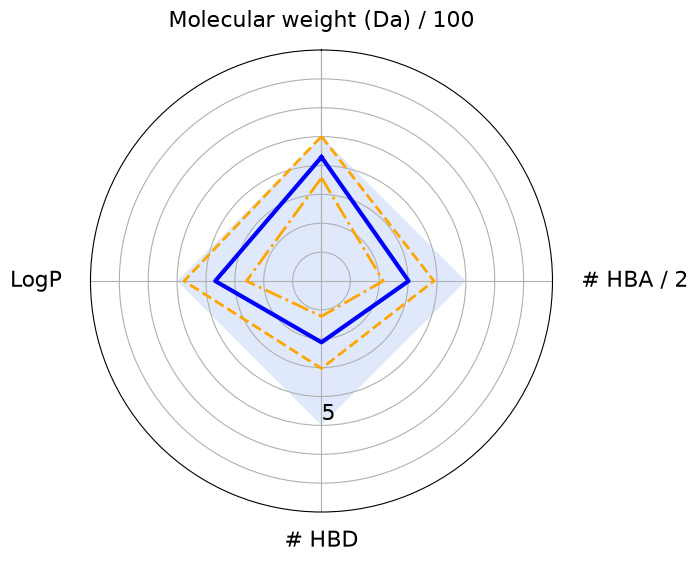

In [74]:
plot_radar(
    cdk2_compounds_ro5_fulfilled_stats,
    thresholds,
    scaled_threshold,
    properties_labels,
    y_max,
)

🔵 Solid blue line — mean value of each property across the dataset  
🟠 Dashed orange — mean + 1 standard deviation (upper spread)  
🟠 Dash-dot orange — mean − 1 standard deviation (lower spread)  
🔵 Shaded blue area — the "rule of five" safe zone (everything inside ≤ 5 on scaled axes)

### 3. Save the filterd .csv file

In [75]:
output_dir = Path.cwd().parent / "data"
output_dir.mkdir(parents=True, exist_ok=True)

cdk2_compounds_ro5_fulfilled.to_csv(output_dir / "CDK_compounds_lipinski.csv", index=False)

print(f"Successfully saved to {output_dir / 'CDK_compounds_lipinski.csv'}")

Successfully saved to /home/adem/Downloads/Drug Discovery journey/Mastering Generative_ml models/Phase_0/VAE/project_01/phase_01/data/CDK_compounds_lipinski.csv


### 4. PAINS/unwanted substrates filtering

In [76]:
cdk2_compounds_ro5_fulfilled.head()

,molecule_chembl_id,kinase,IC50,units,canonical_smiles,pIC50,molecular_weight,n_hba,n_hbd,logp,ro5_fulfilled
0,CHEMBL3694408,CDK9,0.005,nM,COc1ccc(F)cc1-c1cc(NC(=O)COc2ccc(Cl)cn2)ncn1,11.301030,388.073846,6,1,3.3572,True
1,CHEMBL334285,CDK4,0.007,nM,O=C(Nc1cccc2c1C(=O)c1c(-c3ccc(C(=O)N4CCNCC4)s3...,11.154902,507.168873,8,4,1.7637,True
2,CHEMBL3694406,CDK9,0.015,nM,COc1ccc(F)cc1-c1cc(NC(=O)Cc2cccnc2)ncn1,10.823909,338.117904,5,1,2.8675,True
3,CHEMBL3694400,CDK9,0.018,nM,COc1ccc(F)cc1-c1cc(NC(=O)C2CCCNC2)ncn1,10.744727,330.149204,5,2,2.2294,True
4,CHEMBL3694402,CDK9,0.019,nM,COc1ccccc1-c1cc(NC(=O)C2CCC(=O)NC2)ncn1,10.721246,326.137890,5,2,1.6169,True


We drop some columns + add Mol object to each molecules

In [77]:
cdk2_data = cdk2_compounds_ro5_fulfilled
cdk2_data.drop(columns=["molecular_weight", "n_hbd", "n_hba", "logp"], inplace=True)
# Add molecule column
PandasTools.AddMoleculeColumnToFrame(cdk2_data, smilesCol="canonical_smiles")
cdk2_data.head()

,molecule_chembl_id,kinase,IC50,units,canonical_smiles,pIC50,ro5_fulfilled,ROMol
0,CHEMBL3694408,CDK9,0.005,nM,COc1ccc(F)cc1-c1cc(NC(=O)COc2ccc(Cl)cn2)ncn1,11.301030,True,<rdkit.Chem.rdchem.Mol object at 0x735c78f67f40>
1,CHEMBL334285,CDK4,0.007,nM,O=C(Nc1cccc2c1C(=O)c1c(-c3ccc(C(=O)N4CCNCC4)s3...,11.154902,True,<rdkit.Chem.rdchem.Mol object at 0x735c78f67b50>
2,CHEMBL3694406,CDK9,0.015,nM,COc1ccc(F)cc1-c1cc(NC(=O)Cc2cccnc2)ncn1,10.823909,True,<rdkit.Chem.rdchem.Mol object at 0x735c78f67530>
3,CHEMBL3694400,CDK9,0.018,nM,COc1ccc(F)cc1-c1cc(NC(=O)C2CCCNC2)ncn1,10.744727,True,<rdkit.Chem.rdchem.Mol object at 0x735c78f642e0>
4,CHEMBL3694402,CDK9,0.019,nM,COc1ccccc1-c1cc(NC(=O)C2CCC(=O)NC2)ncn1,10.721246,True,<rdkit.Chem.rdchem.Mol object at 0x735c78f67e60>


#### 4.1 PAINS filtering

Now we filter PAINS 

In [78]:
# initialize filter
params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
catalog = FilterCatalog(params)

In [79]:
# search for PAINS
matches = []
clean = []
for index, row in tqdm(cdk2_data.iterrows(), total=cdk2_data.shape[0]):
    molecule = Chem.MolFromSmiles(row['canonical_smiles'])
    entry = catalog.GetFirstMatch(molecule)  # Get the first matching PAINS
    if entry is not None:
        # store PAINS information
        matches.append(
            {
                "chembl_id": row.molecule_chembl_id,
                "rdkit_molecule": molecule,
                "pains": entry.GetDescription().capitalize(),
            }
        )
    else:
        # collect indices of molecules without PAINS
        clean.append(index)

matches = pd.DataFrame(matches)
cdk2_data = cdk2_data.loc[clean]  # keep molecules without PAINS

  0%|          | 0/6497 [00:00<?, ?it/s]

In [80]:
# NBVAL_CHECK_OUTPUT
print(f"Number of PAINS compounds : {len(matches)}")
print(f"Number of non PAINS compounds : {len(cdk2_data)}")

Number of PAINS compounds : 362
Number of non PAINS compounds : 6135


In [81]:
output_dir = Path.cwd().parent / "data"
output_dir.mkdir(parents=True, exist_ok=True)

cdk2_data.to_csv(output_dir / "CDK2_compounds_lipinski_NOPAINS.csv", index=False)

print(f"Successfully saved to {output_dir / 'CDK2_compounds_lipinski_NOPAINS.csv'}")

Successfully saved to /home/adem/Downloads/Drug Discovery journey/Mastering Generative_ml models/Phase_0/VAE/project_01/phase_01/data/CDK2_compounds_lipinski_NOPAINS.csv


#### 4.2 Unwanted substrate filtering BRENK filtering

In [82]:
params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.BRENK)
catalog = FilterCatalog(params)

def has_brenk_alert(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False
    return catalog.HasMatch(mol)

cdk2_data["has_brenk"] = cdk2_data["canonical_smiles"].apply(has_brenk_alert)

n_flagged = cdk2_data["has_brenk"].sum()
n_total = len(cdk2_data)
print(f"Molecules with Brenk alert: {n_flagged} / {n_total} ({n_flagged/n_total:.1%})")

Molecules with Brenk alert: 1061 / 6135 (17.3%)


In [83]:
def get_brenk_alert(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    entry = catalog.GetFirstMatch(mol)
    return entry.GetDescription() if entry else None

In [84]:
cdk2_data["brenk_alert"] = cdk2_data["canonical_smiles"].apply(get_brenk_alert)
cdk2_data = cdk2_data[cdk2_data["brenk_alert"].isna()].reset_index(drop=True)

In [85]:
cdk2_data.shape

(5074, 10)

In [86]:
cdk2_data.drop(columns=["brenk_alert"], inplace=True)

### 5. Save the filterd .csv file

In [87]:
output_dir = Path.cwd().parent / "data"
output_dir.mkdir(parents=True, exist_ok=True)

cdk2_data.to_csv(output_dir / "CDK2_compounds_lipinski_NOPAINS_NOBRENKS.csv", index=False)

print(f"Successfully saved to {output_dir / 'CDK2_compounds_lipinski_NOPAINS_NOBRENKS.csv'}")

Successfully saved to /home/adem/Downloads/Drug Discovery journey/Mastering Generative_ml models/Phase_0/VAE/project_01/phase_01/data/CDK2_compounds_lipinski_NOPAINS_NOBRENKS.csv
